<a href="https://colab.research.google.com/github/amit-sahu-a11y/ML_projects_for_practice/blob/main/modeltrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Training a Simple Machine Learning Model (Linear Regression)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### 1. Generate Synthetic Data
Let's create a simple dataset where `y` is linearly dependent on `x` with some noise.

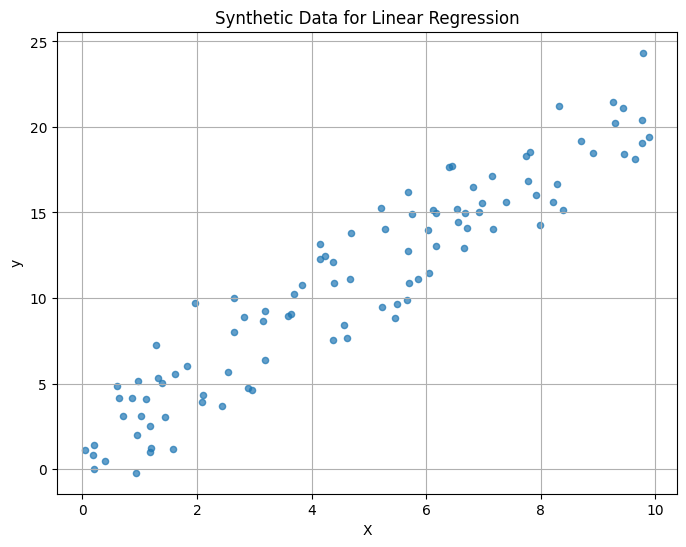

In [9]:
# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature
y = 2 * X + 1 + np.random.randn(100, 1) * 2 # y = 2x + 1 + noise

plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=20, alpha=0.7)
plt.title('Synthetic Data for Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

### 2. Split Data into Training and Testing Sets
We'll split the data to evaluate our model's performance on unseen data.

In [10]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training data shape: X_train=(80, 1), y_train=(80, 1)
Testing data shape: X_test=(20, 1), y_test=(20, 1)


### 3. Define and Train the Model
We'll use `LinearRegression` from scikit-learn.

In [11]:
# Create a linear regression model
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)

print(f"Model Coefficients (slope): {model.coef_[0][0]:.2f}")
print(f"Model Intercept: {model.intercept_[0]:.2f}")

Model Coefficients (slope): 2.00
Model Intercept: 1.41


### 4. Evaluate the Model
Let's make predictions on the test set and evaluate the model's performance using Mean Squared Error (MSE) and R-squared.

In [12]:
# Make predictions using the testing set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 3.67
R-squared (R2): 0.85


### 5. Visualize the Results
Let's plot the original data, training data, and the regression line to see how well the model fits.

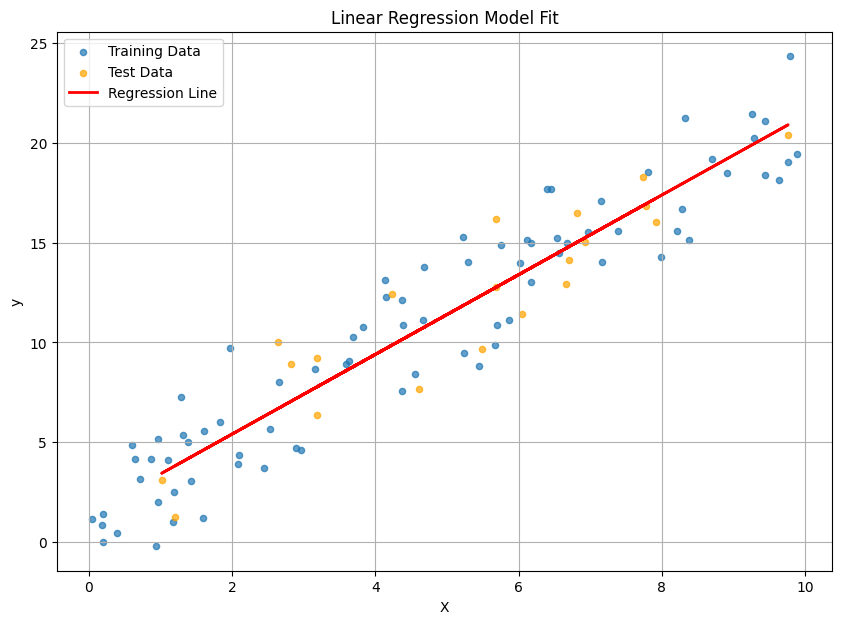

In [13]:
# Plot the results
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, s=20, alpha=0.7, label='Training Data')
plt.scatter(X_test, y_test, s=20, alpha=0.7, color='orange', label='Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression Model Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Improving the Model with Polynomial Regression

Since our data generation involved a linear relationship with noise, the linear model performed well. However, in real-world scenarios, relationships might be non-linear. Polynomial regression is a form of linear regression in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial. It can capture non-linear relationships by transforming the original features into polynomial features.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Define the degree of the polynomial
degree = 2 # Let's try a quadratic relationship

# Create a polynomial features transformer and a linear regression model
polynomial_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Train the polynomial model
polynomial_model.fit(X_train, y_train)

print(f"Polynomial Regression Model (degree={degree}) trained.")

Polynomial Regression Model (degree=2) trained.


### Evaluate the Polynomial Model

Let's see how the polynomial model performs on the test set.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Make predictions with the polynomial model
y_pred_poly = polynomial_model.predict(X_test)

# Evaluate the polynomial model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Model (degree={degree}) Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Polynomial Model (degree={degree}) R-squared (R2): {r2_poly:.2f}")

# Compare with the simple linear model
print(f"\nOriginal Linear Model MSE: {mse:.2f}")
print(f"Original Linear Model R2: {r2:.2f}")

Polynomial Model (degree=2) Mean Squared Error (MSE): 3.65
Polynomial Model (degree=2) R-squared (R2): 0.85

Original Linear Model MSE: 3.67
Original Linear Model R2: 0.85


### Visualize the Polynomial Regression Results

Now, let's visualize how the polynomial curve fits the data.

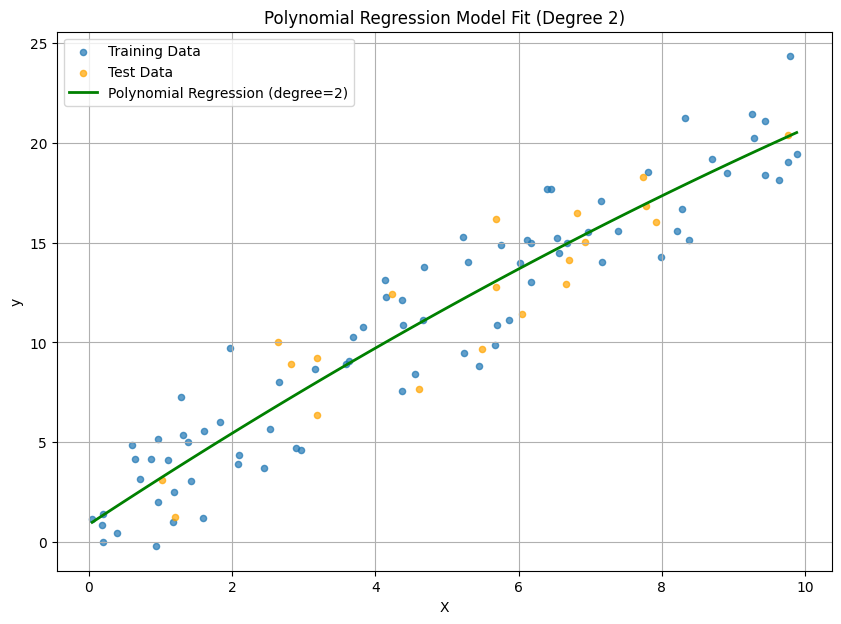

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# For plotting the polynomial curve, we need a sorted range of X values
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred_range_poly = polynomial_model.predict(X_range)

plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, s=20, alpha=0.7, label='Training Data')
plt.scatter(X_test, y_test, s=20, alpha=0.7, color='orange', label='Test Data')
plt.plot(X_range, y_pred_range_poly, color='green', linewidth=2, label=f'Polynomial Regression (degree={degree})')
plt.title(f'Polynomial Regression Model Fit (Degree {degree})')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()